# Deep Learning: FC, CNN, RNN, GAN, Autoencoders
**Author:** Kseniia Tikhonova  
**Description:** Comparative study of deep learning architectures across four domains: synthetic data, computer vision, sequential modelling, and generative models.

## Section 1: Reproducibility — Seeds & Device Config
All seeds are set before any data loading or model initialisation. The remaining source of nondeterminism is GPU kernel non-determinism in cuDNN backward passes (e.g. Conv2D). Setting `TF_DETERMINISTIC_OPS=1` reduces but does not fully eliminate this on all hardware/driver combinations.

In [1]:
import os, re, csv, random, struct, unittest
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
import nltk
from datetime import datetime
from skimage import io, transform
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras import layers, Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense, Flatten, Dropout, Input,
    Conv2D, MaxPooling2D, UpSampling2D, Conv2DTranspose,
    LSTM, Embedding, BatchNormalization, LeakyReLU,
    GlobalAveragePooling2D, Reshape,
    RandomFlip, RandomRotation, RandomZoom, RandomContrast
)
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, CSVLogger
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.losses import BinaryCrossentropy, MeanSquaredError
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.applications import ResNet50, VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from nltk.stem import WordNetLemmatizer

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"

print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.19.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Section 2: Experiment Logger
Tracks every run (name, params, metrics, timestamp) into a single `experiment_log.csv`. This was the primary tool used to compare architectures and inform decisions — e.g. which ResNet variant to proceed with.

In [2]:
LOG_FILE = "experiment_log.csv"

def log_experiment(name, params, metrics):
    row = {"timestamp": datetime.now().isoformat(), "experiment": name}
    row.update(params)
    row.update(metrics)
    file_exists = os.path.isfile(LOG_FILE)
    with open(LOG_FILE, "a", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=row.keys())
        if not file_exists:
            writer.writeheader()
        writer.writerow(row)
    print(f"[LOG] {name} -> {metrics}")

## Section 3: Synthetic Data | Fully Connected Networks
Binary classification: points sampled from a disk (r=0.8) vs. an annulus (r=1, R=2). Three FC architectures are compared to demonstrate the effect of model capacity on non-linear decision boundaries. The best model is also evaluated on Gaussian-noisy data.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


[LOG] FC-2x2 -> {'test_accuracy': 0.7799999713897705}
[LOG] FC-3x1 -> {'test_accuracy': 0.9549999833106995}
[LOG] FC-16-8 -> {'test_accuracy': 1.0}
[LOG] FC-16-8-noisy -> {'test_accuracy': 0.9549999833106995}
FC results: {'FC-2x2': 0.78, 'FC-3x1': 0.955, 'FC-16-8': 1.0}
FC-16-8 noisy: 0.955


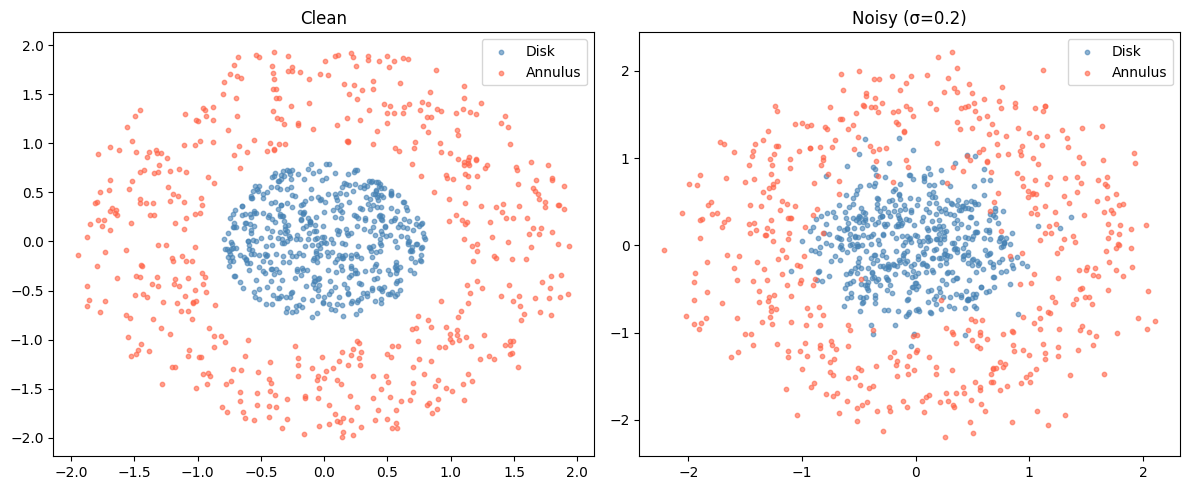

In [3]:
def generate_disk_annulus(n=1000, noise_std=0.0, seed=SEED):
    rng = np.random.default_rng(seed)
    pts = rng.uniform(-0.8, 0.8, size=(n * 4, 2))
    pts = pts[np.linalg.norm(pts, axis=1) < 0.8][:n // 2]
    y0 = np.zeros(len(pts))
    ring = rng.uniform(-2, 2, size=(n * 10, 2))
    norms = np.linalg.norm(ring, axis=1)
    ring = ring[(norms > 1) & (norms < 2)][:n // 2]
    y1 = np.ones(len(ring))
    X = np.vstack([pts, ring])
    y = np.concatenate([y0, y1])
    if noise_std > 0:
        X += rng.normal(0, noise_std, size=X.shape)
    return X, y

def build_fc(neurons_per_layer):
    layer_list = []
    for i, n in enumerate(neurons_per_layer[:-1]):
        if i == 0:
            layer_list.append(Dense(n, activation="relu", input_shape=(2,)))
        else:
            layer_list.append(Dense(n, activation="relu"))
    layer_list.append(Dense(neurons_per_layer[-1], activation="sigmoid"))
    m = Sequential(layer_list)
    m.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return m

X, y = generate_disk_annulus(n=1000)
X_noisy, y_noisy = generate_disk_annulus(n=1000, noise_std=0.2)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=SEED)
X_tr_n, X_te_n, y_tr_n, y_te_n = train_test_split(X_noisy, y_noisy, test_size=0.2, random_state=SEED)

fc_configs = {"FC-2x2": [2,1], "FC-3x1": [3,1], "FC-16-8": [16,8,1]}
fc_results = {}
for name, arch in fc_configs.items():
    m = build_fc(arch)
    m.fit(X_tr, y_tr, epochs=50, verbose=0)
    _, acc = m.evaluate(X_te, y_te, verbose=0)
    fc_results[name] = round(acc, 4)
    log_experiment(name, {"arch": str(arch), "noise": False}, {"test_accuracy": acc})

best_fc = build_fc([16, 8, 1])
best_fc.fit(X_tr_n, y_tr_n, epochs=20, verbose=0)
_, acc_noisy = best_fc.evaluate(X_te_n, y_te_n, verbose=0)
log_experiment("FC-16-8-noisy", {"arch": "[16,8,1]", "noise": True}, {"test_accuracy": acc_noisy})
print("FC results:", fc_results)
print("FC-16-8 noisy:", round(acc_noisy, 4))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (X_plot, y_plot, title) in zip(axes, [(X, y, "Clean"), (X_noisy, y_noisy, "Noisy (σ=0.2)")]):
    ax.scatter(X_plot[y_plot==0, 0], X_plot[y_plot==0, 1], c="steelblue", label="Disk", s=10, alpha=0.6)
    ax.scatter(X_plot[y_plot==1, 0], X_plot[y_plot==1, 1], c="tomato",    label="Annulus", s=10, alpha=0.6)
    ax.set_title(title); ax.legend()
plt.tight_layout()
plt.savefig("synthetic_data.png", dpi=150)
plt.show()

## Section 4: CNN on MNIST
Convolutional architecture with two Conv+MaxPool+Dropout blocks. Target: val_accuracy > 98%. Training curves saved to `mnist_cnn_log.csv`.

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.8946 - loss: 0.3414 - val_accuracy: 0.9770 - val_loss: 0.0681
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9649 - loss: 0.1171 - val_accuracy: 0.9843 - val_loss: 0.0459
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9737 - loss: 0.0883 - val_accuracy: 0.9867 - val_loss: 0.0376
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9780 - loss: 0.0739 - val_accuracy: 0.9888 - val_loss: 0.0317
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9799 - loss: 0.0669 - val_accuracy: 0.9901 - val_loss: 0.0259
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9818 - loss: 0.0610 - val_accuracy: 0.9915 - val_loss: 0.0247
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9829 - loss: 0.0530 - val_accuracy: 0.9924 - val_loss: 0.0234
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9851 - loss: 0.0493 - val_accuracy: 0.

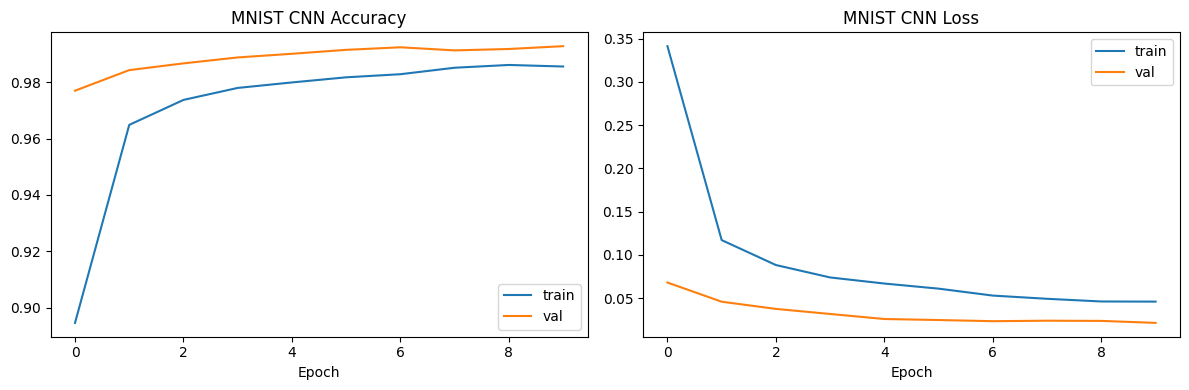

In [4]:
(x_tr_m, y_tr_m), (x_te_m, y_te_m) = tf.keras.datasets.mnist.load_data()
x_tr_m = x_tr_m[..., np.newaxis] / 255.0
x_te_m = x_te_m[..., np.newaxis] / 255.0
y_tr_m_cat = tf.keras.utils.to_categorical(y_tr_m, 10)
y_te_m_cat = tf.keras.utils.to_categorical(y_te_m, 10)

cnn_mnist = Sequential([
    Conv2D(32, (3,3), activation="relu", input_shape=(28,28,1)),
    MaxPooling2D((2,2)), Dropout(0.25),
    Conv2D(64, (3,3), activation="relu"),
    MaxPooling2D((2,2)), Dropout(0.25),
    Flatten(), Dense(128, activation="relu"), Dropout(0.5),
    Dense(10, activation="softmax"),
])
cnn_mnist.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
hist_mnist = cnn_mnist.fit(x_tr_m, y_tr_m_cat, batch_size=128, epochs=10, verbose=1,
                            validation_data=(x_te_m, y_te_m_cat),
                            callbacks=[CSVLogger("mnist_cnn_log.csv")])
score = cnn_mnist.evaluate(x_te_m, y_te_m_cat, verbose=0)
log_experiment("CNN-MNIST", {"batch_size": 128, "epochs": 10}, {"test_loss": score[0], "test_accuracy": score[1]})

plt.figure(figsize=(12, 4))
plt.subplot(1,2,1)
plt.plot(hist_mnist.history["accuracy"], label="train")
plt.plot(hist_mnist.history["val_accuracy"], label="val")
plt.title("MNIST CNN Accuracy"); plt.xlabel("Epoch"); plt.legend()
plt.subplot(1,2,2)
plt.plot(hist_mnist.history["loss"], label="train")
plt.plot(hist_mnist.history["val_loss"], label="val")
plt.title("MNIST CNN Loss"); plt.xlabel("Epoch"); plt.legend()
plt.tight_layout(); plt.savefig("mnist_cnn_curves.png", dpi=150); plt.show()

## Section 5: Convolutional Autoencoder | MNIST Reconstruction
Symmetric encoder-decoder. Loss: binary crossentropy on pixel values (images normalised to [0,1]).

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - loss: 0.1052 - val_loss: 0.0732
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0718 - val_loss: 0.0696
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0693 - val_loss: 0.0682
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0680 - val_loss: 0.0672
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0672 - val_loss: 0.0666
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0666 - val_loss: 0.0659
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0661 - val_loss: 0.0655
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0657 - val_loss: 0.0652
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0653 - val_loss: 0.0648
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0650 - val_loss: 0.0644
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step


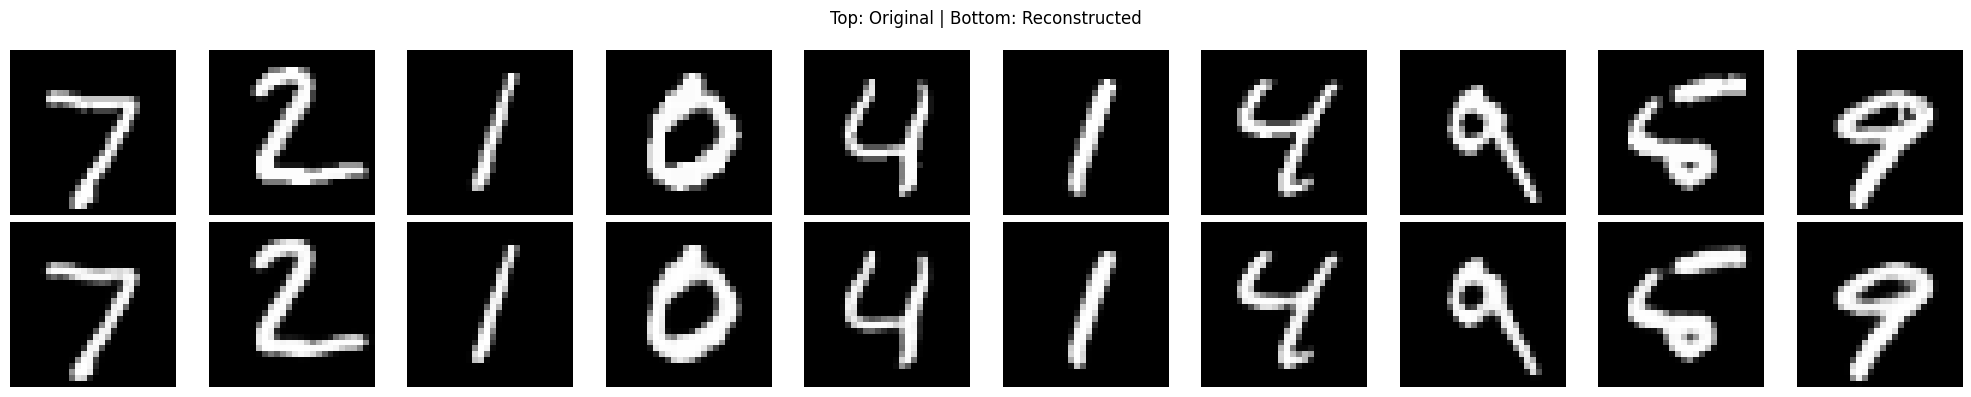

In [5]:
inp = Input(shape=(28, 28, 1))
x = Conv2D(32, (3,3), activation="relu", padding="same")(inp)
x = MaxPooling2D((2,2), padding="same")(x)
x = Conv2D(64, (3,3), activation="relu", padding="same")(x)
encoded = MaxPooling2D((2,2), padding="same")(x)
x = Conv2D(64, (3,3), activation="relu", padding="same")(encoded)
x = UpSampling2D((2,2))(x)
x = Conv2D(32, (3,3), activation="relu", padding="same")(x)
x = UpSampling2D((2,2))(x)
decoded = Conv2D(1, (3,3), activation="sigmoid", padding="same")(x)

autoencoder_mnist = Model(inp, decoded)
autoencoder_mnist.compile(optimizer="adam", loss="binary_crossentropy")
autoencoder_mnist.fit(x_tr_m, x_tr_m, epochs=10, batch_size=128, shuffle=True,
                      validation_data=(x_te_m, x_te_m), verbose=1)

decoded_imgs = autoencoder_mnist.predict(x_te_m[:10])
plt.figure(figsize=(20, 4))
for i in range(10):
    plt.subplot(2, 10, i+1); plt.imshow(x_te_m[i].reshape(28,28), cmap="gray"); plt.axis("off")
    plt.subplot(2, 10, i+11); plt.imshow(decoded_imgs[i].reshape(28,28), cmap="gray"); plt.axis("off")
plt.suptitle("Top: Original | Bottom: Reconstructed")
plt.tight_layout(); plt.savefig("autoencoder_mnist.png", dpi=150); plt.show()